In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set up
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# XGB with True + Pseudo Labels (Full dataset)

In [2]:
df = pd.read_csv('TRUE_PSEUDO_featData.csv')

In [6]:
df.shape

(1406, 52)

In [34]:
# Define features and target
descr = ['CoordinationNumber','PseudoLabelled','NumElementsSurface',
         'meanAtomicRadius','maxAtomicRadius','minAtomicRadius','stdAtomicRadius',	
         'meanAtomicMass','maxAtomicMass','minAtomicMass','stdAtomicMass',
         'meanAffinity','maxAffinity','minAffinity','stdAffinity',
         'meanDensity','maxDensity','minDensity','stdDensity',
         'meanGroup','maxGroup','minGroup','stdGroup',
         'meanMeltingP','maxMeltingP','minMeltingP','stdMeltingP',
         'meanIon','maxIon','minIon','stdIon',
         'meanElectronegativity','maxElectronegativity','minElectronegativity','stdElectronegativity',
         'meanPcount','maxPcount','minPcount','stdPcount',
         'meanDcount','maxDcount','minDcount','stdDcount',
]

target = 'ReactionEnergy'

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train, y_train)

# Best model and parameters
xgb_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate model
y_pred = xgb_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nOptimized RMSE: {rmse:.2f}")
print(f"Optimized MAE: {mae:.2f}")
print(f"Optimized R² Score: {r2:.3f}")


Fitting 3 folds for each of 192 candidates, totalling 576 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1.0}

Optimized RMSE: 0.28
Optimized MAE: 0.19
Optimized R² Score: 0.828


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [5]:
!pip install shap
import shap

PermutationExplainer explainer: 1125it [00:45, 19.22it/s]                       

Top 10 SHAP features: ['CoordinationNumber', 'meanGroup', 'meanDcount', 'meanMeltingP', 'minGroup', 'meanElectronegativity', 'maxAtomicRadius', 'meanAtomicRadius', 'minDensity', 'PseudoLabelled', 'meanAtomicMass', 'minAffinity', 'meanAffinity', 'meanIon', 'maxAffinity']



/var/folders/db/r9nl4bjj49vbnwtt3wgg825h0000gn/T/ipykernel_12020/2386797641.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=10)


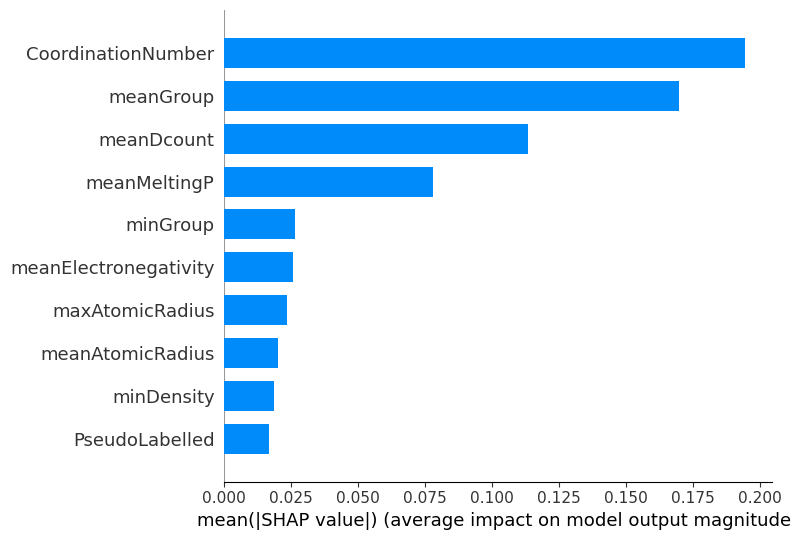

In [35]:
explainer = shap.Explainer(xgb_model.predict, X_train)
shap_values = explainer(X_train)


# 4. Compute mean absolute SHAP value per feature (global importance)

shap_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='Importance', ascending=False)

shap_top_features = shap_importance['Feature'].head(15).tolist()
print("Top 10 SHAP features:", shap_top_features)

shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=10)

# XGB with True + Pseudo Labels (Top 10 features only)

In [40]:
X_train_top10 = X_train[['CoordinationNumber', 'meanGroup', 'meanDcount', 
                         'meanMeltingP', 'minGroup', 'meanElectronegativity', 
                         'maxAtomicRadius', 'meanAtomicRadius', 'minDensity', 'meanAtomicMass', 'minAffinity'
                        ]]
X_test_top10 = X_test[['CoordinationNumber', 'meanGroup', 'meanDcount', 
                       'meanMeltingP', 'minGroup', 'meanElectronegativity',
                       'maxAtomicRadius', 'meanAtomicRadius', 'minDensity', 'meanAtomicMass', 'minAffinity']]

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] }

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train_top10, y_train)

# Best model and parameters
model_top10 = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)


# Evaluate model
y_pred_top10 = model_top10.predict(X_test_top10)


rmse_top10 = mean_squared_error(y_test, y_pred_top10, squared=False)
mae = mean_absolute_error(y_test, y_pred_top10)
r2 = r2_score(y_test, y_pred_top10)

print(f"\nOptimized RMSE: {rmse:.2f}")
print(f"Optimized MAE: {mae:.2f}")
print(f"Optimized R² Score: {r2:.3f}")



Fitting 3 folds for each of 192 candidates, totalling 576 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1.0}

Optimized RMSE: 0.28
Optimized MAE: 0.19
Optimized R² Score: 0.822


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# XGB with True Labels ONLY

In [7]:
df = pd.read_csv('true_ONLY_featureData.csv')

In [8]:
print(df.shape)
df.columns

(689, 59)


Index(['Unnamed: 0', 'surfaceComposition', 'ChemicalComposition', 'Site',
       'O*_energy', 'OH*_energy', 'CoordinationNumber', 'NumElementsSurface',
       'ConfigEntropy_JmolK', 'ReducedComposition', 'meanAtomicRadius',
       'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius',
       'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass', 'stdAtomicMass',
       'meanPcount', 'maxPcount', 'minPcount', 'stdPcount', 'meanDcount',
       'maxDcount', 'minDcount', 'stdDcount', 'meanAffinity', 'maxAffinity',
       'minAffinity', 'stdAffinity', 'meanDensity', 'maxDensity', 'minDensity',
       'stdDensity', 'meanGroup', 'maxGroup', 'minGroup', 'stdGroup',
       'meanMeltingP', 'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon',
       'maxIon', 'minIon', 'stdIon', 'meanElectronegativity',
       'maxElectronegativity', 'minElectronegativity', 'stdElectronegativity',
       'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy', 'stdEnthalpy',
       'ReactionEnergy', 'Facet_100', 'Facet_10

In [11]:
# Define features and target
descr = ["CoordinationNumber", "NumElementsSurface", "ConfigEntropy_JmolK",
    "meanAtomicRadius", "maxAtomicRadius", "minAtomicRadius", "stdAtomicRadius",
    "meanAtomicMass", "maxAtomicMass", "minAtomicMass", "stdAtomicMass",
    "meanAffinity", "maxAffinity", "minAffinity", "stdAffinity",
    "meanDensity", "maxDensity", "minDensity", "stdDensity",
    "meanGroup", "maxGroup", "minGroup", "stdGroup",
    "meanMeltingP", "maxMeltingP", "minMeltingP", "stdMeltingP",
    "meanIon", "maxIon", "minIon", "stdIon",
    "meanElectronegativity", "maxElectronegativity", "minElectronegativity", "stdElectronegativity",
    "Facet_100", "Facet_101", "Facet_110", "Facet_111",
    "meanPcount", "maxPcount", "minPcount", "stdPcount",
    "meanDcount", "maxDcount", "minDcount", "stdDcount",
    'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy', 'stdEnthalpy',
    'Facet_100', 'Facet_101', 'Facet_110', 'Facet_111'
]

target = "ReactionEnergy"

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train.values, y_train.values)

# Best model and parameters
xgb_model2 = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate model
y_pred = xgb_model2.predict(X_test.values)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nOptimized RMSE: {rmse:.2f}")
print(f"Optimized MAE: {mae:.2f}")
print(f"Optimized R² Score: {r2:.3f}")


Fitting 3 folds for each of 192 candidates, totalling 576 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1.0}

Optimized RMSE: 0.32
Optimized MAE: 0.24
Optimized R² Score: 0.847


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


PermutationExplainer explainer: 552it [00:33, 10.89it/s]                        
/var/folders/db/r9nl4bjj49vbnwtt3wgg825h0000gn/T/ipykernel_39550/3252119672.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=10)


Top 10 SHAP features: ['meanGroup', 'CoordinationNumber', 'meanDcount', 'meanEnthalpy', 'minAtomicMass', 'meanMeltingP', 'maxAtomicRadius', 'meanAtomicRadius', 'meanAtomicMass', 'meanIon', 'meanElectronegativity', 'minDensity', 'minAffinity', 'minGroup', 'minAtomicRadius']


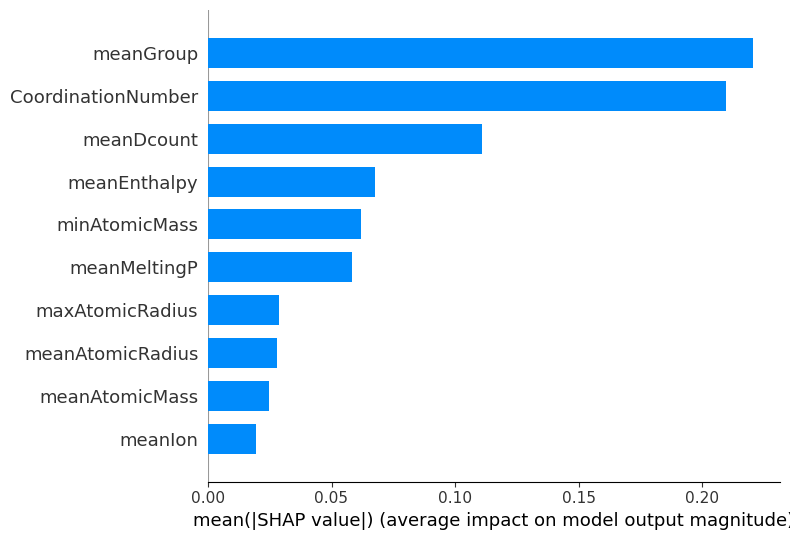

In [12]:
import shap

explainer = shap.Explainer(xgb_model2.predict, X_train.values)
shap_values = explainer(X_train)


# 4. Compute mean absolute SHAP value per feature (global importance)

shap_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='Importance', ascending=False)

shap_top_features = shap_importance['Feature'].head(15).tolist()
print("Top 10 SHAP features:", shap_top_features)

shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=10)

# XGB with True Labels (top 10 features only)

In [17]:
X_train_top10 = X_train[['meanGroup', 'CoordinationNumber', 'meanDcount', 
                           'minAtomicMass', 'meanMeltingP', 
                          'maxAtomicRadius', 'meanAtomicRadius', 'meanAtomicMass', 'meanIon',
                        'meanElectronegativity', 'minDensity', 'minAffinity', 'minGroup', 'minAtomicRadius']]
X_test_top10 = X_test[['meanGroup', 'CoordinationNumber', 'meanDcount', 
                         'minAtomicMass', 'meanMeltingP', 
                          'maxAtomicRadius', 'meanAtomicRadius', 'meanAtomicMass', 'meanIon',
                      'meanElectronegativity', 'minDensity', 'minAffinity', 'minGroup', 'minAtomicRadius']]

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] }

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train_top10, y_train)

# Best model and parameters
model2_top10 = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)


# Evaluate model
y_pred_top10 = model2_top10.predict(X_test_top10)


rmse_top10 = mean_squared_error(y_test, y_pred_top10, squared=False)
mae = mean_absolute_error(y_test, y_pred_top10)
r2 = r2_score(y_test, y_pred_top10)

print(f"\nOptimized RMSE: {rmse:.2f}")
print(f"Optimized MAE: {mae:.2f}")
print(f"Optimized R² Score: {r2:.3f}")

Fitting 3 folds for each of 192 candidates, totalling 576 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1.0}

Optimized RMSE: 0.32
Optimized MAE: 0.24
Optimized R² Score: 0.851


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
